<a href="https://www.kaggle.com/code/aamir28/from-campus-to-career-what-predicts-placement?scriptVersionId=342468000" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


<div style="background:linear-gradient(135deg,#3A1F6B 0%,#8C2E7A 45%,#E0713D 100%); padding:46px 42px; border-radius:20px; font-family:'Segoe UI',Helvetica,Arial,sans-serif;">

  <div style="display:flex; align-items:center; gap:10px; margin-bottom:14px;">
    <span style="font-size:22px;"></span>
    <span style="font-size:12px; font-weight:800; color:#FFE1C4; letter-spacing:2px; text-transform:uppercase;">Career Launch Analytics</span>
  </div>

  <h1 style="margin:0 0 8px 0; font-size:36px; color:#FFFFFF; font-weight:800; letter-spacing:-0.5px; text-shadow:0 2px 12px rgba(0,0,0,0.15);">
    From Campus to Career: What Predicts Placement?
  </h1>
  <p style="margin:0 0 30px 0; font-size:15px; color:#FFE1C4; max-width:660px;">
    50,000 students — skills, activities, and outcomes — tracing the path from CGPA and coding ability to job offers and starting salary
  </p>

  <div style="display:flex; gap:14px; flex-wrap:wrap;">
    <div style="background:rgba(255,255,255,0.16); backdrop-filter:blur(4px); border-radius:14px; padding:16px 20px; flex:1; min-width:130px;">
      <div style="color:#FFFFFF; font-size:24px; font-weight:800;">78.1%</div>
      <div style="font-size:11px; color:#FFE1C4; margin-top:2px;">placement rate</div>
    </div>
    <div style="background:rgba(255,255,255,0.16); backdrop-filter:blur(4px); border-radius:14px; padding:16px 20px; flex:1; min-width:130px;">
      <div style="color:#FFFFFF; font-size:24px; font-weight:800;">8</div>
      <div style="font-size:11px; color:#FFE1C4; margin-top:2px;">majors</div>
    </div>
    <div style="background:rgba(255,255,255,0.16); backdrop-filter:blur(4px); border-radius:14px; padding:16px 20px; flex:1; min-width:130px;">
      <div style="color:#FFFFFF; font-size:24px; font-weight:800;">17</div>
      <div style="font-size:11px; color:#FFE1C4; margin-top:2px;">career fields</div>
    </div>
    <div style="background:rgba(255,255,255,0.16); backdrop-filter:blur(4px); border-radius:14px; padding:16px 20px; flex:1; min-width:130px;">
      <div style="color:#FFFFFF; font-size:24px; font-weight:800;">$68.9K</div>
      <div style="font-size:11px; color:#FFE1C4; margin-top:2px;">avg. starting salary</div>
    </div>
  </div>

  <p style="margin:24px 0 0 0; font-size:12.5px; color:#F3D4C4;">
    Author: <b style="color:#FFFFFF;">Muhammad Aamir</b> &nbsp;|&nbsp; Targets: <code>Placement_Status</code> &amp; <code>Starting_Salary_USD</code>
  </p>

</div>



<div style="background:#FBF3EE; border-radius:16px; padding:22px 28px; font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#3A1F6B;">
<h3 style="margin-top:0; font-weight:800; color:#8C2E7A; letter-spacing:0.5px; font-size:13px; text-transform:uppercase;">🎓 Roadmap</h3>
<ol style="line-height:2; font-size:14.5px; color:#4A3550; columns:2; column-gap:32px;">
<li><a href="#setup" style="color:#E0713D; text-decoration:none;">Setup &amp; Launch Styling</a></li>
<li><a href="#firstlook" style="color:#E0713D; text-decoration:none;">First Look at the Cohort</a></li>
<li><a href="#quality" style="color:#E0713D; text-decoration:none;">Data Quality Check</a></li>
<li><a href="#profile" style="color:#E0713D; text-decoration:none;">Student Profile Overview</a></li>
<li><a href="#skills" style="color:#E0713D; text-decoration:none;">Academic &amp; Skills Landscape</a></li>
<li><a href="#placement" style="color:#E0713D; text-decoration:none;">The Placement Landscape</a></li>
<li><a href="#formula" style="color:#E0713D; text-decoration:none;">Decoding the Employability Score</a></li>
<li><a href="#drivers" style="color:#E0713D; text-decoration:none;">What Actually Drives Placement</a></li>
<li><a href="#salary" style="color:#E0713D; text-decoration:none;">The Salary Landscape</a></li>
<li><a href="#corr" style="color:#E0713D; text-decoration:none;">Correlation Check</a></li>
<li><a href="#dashboard" style="color:#E0713D; text-decoration:none;">Launch Dashboard</a></li>
<li><a href="#model" style="color:#E0713D; text-decoration:none;">Predicting Placement</a></li>
<li><a href="#conclusion" style="color:#E0713D; text-decoration:none;">Closing Notes</a></li>
</ol>
</div>


<h2 id="setup" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#3A1F6B;">🚀 1. Setup &amp; Launch Styling</h2>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ---- "Career Launch" sunrise gradient palette ----
BG        = '#FBF3EE'
PANEL     = '#FFFFFF'
INK       = '#2E2138'
INK_SOFT  = '#8B7B93'
VIOLET    = '#3A1F6B'
MAGENTA   = '#8C2E7A'
ORANGE    = '#E0713D'
GOLD      = '#F0B429'
TEAL      = '#2E9E8C'
GRID      = '#F0E4DA'

PLACED_COLORS = {'Placed': TEAL, 'Not Placed': MAGENTA}
TIER_COLORS = {'Tier 1': GOLD, 'Tier 2': ORANGE, 'Tier 3': MAGENTA, 'No Company': INK_SOFT}
PALETTE_CAT = [VIOLET, ORANGE, TEAL, GOLD, MAGENTA]

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor': PANEL,
    'savefig.facecolor': BG,
    'axes.edgecolor': GRID,
    'axes.labelcolor': INK,
    'text.color': INK,
    'xtick.color': INK_SOFT,
    'ytick.color': INK_SOFT,
    'axes.grid': True,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'grid.alpha': 0.9,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

sns.set_palette(sns.color_palette(PALETTE_CAT))

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title: ax.set_title(title, color=INK, pad=12, fontsize=13)
    if xlabel: ax.set_xlabel(xlabel, color=INK_SOFT)
    if ylabel: ax.set_ylabel(ylabel, color=INK_SOFT)
    ax.spines['left'].set_color(GRID)
    ax.spines['bottom'].set_color(GRID)
    return ax

print("Launch styling loaded.")


Launch styling loaded.


<h2 id="firstlook" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#3A1F6B;">📋 2. First Look at the Cohort</h2>

In [2]:

df = pd.read_csv('/kaggle/input/datasets/mobeenfatimah/student-career-success-prediction-dataset/student_career_success_dataset.csv')
print(f"Shape: {df.shape[0]:,} students x {df.shape[1]} columns\n")
df.head(6)


Shape: 50,000 students x 29 columns



,Student_ID,Age,Gender,University_Year,Major,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Academic_Performance,Programming_Skill,...,Teamwork,Problem_Solving,English_Proficiency,Interview_Score,Employability_Score,Placement_Status,Company_Tier,Career_Field,Placement_Mode,Starting_Salary_USD
0,ST000001,22,Male,Sophomore,Computer Science,86,21,3.28,Good,9,...,7,8,Advanced,72,231.70,Placed,Tier 1,Backend Developer,Campus Placement,72082
1,ST000002,20,Female,Freshman,Computer Science,64,18,2.53,Poor,6,...,6,5,Basic,59,157.45,Not Placed,No Company,Not Placed,Not Applicable,0
2,ST000003,23,Male,Senior,Information Technology,75,19,2.83,Average,8,...,8,7,Advanced,76,203.45,Placed,Tier 1,IT Support Engineer,Campus Placement,94898
3,ST000004,23,Female,Senior,Information Technology,80,19,2.80,Average,5,...,6,6,Intermediate,67,171.50,Not Placed,No Company,Not Placed,Not Applicable,0
4,ST000005,23,Female,Senior,Software Engineering,73,19,2.93,Average,9,...,8,9,Advanced,82,225.45,Placed,Tier 1,Software Engineer,Internship Conversion,85256
5,ST000006,21,Male,Senior,Computer Science,85,32,3.41,Good,9,...,6,9,Intermediate,72,210.05,Placed,Tier 1,Software Engineer,Off-Campus,109920


In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   University_Year        50000 non-null  object 
 4   Major                  50000 non-null  object 
 5   Attendance_Percentage  50000 non-null  int64  
 6   Study_Hours_Per_Week   50000 non-null  int64  
 7   CGPA                   50000 non-null  float64
 8   Academic_Performance   50000 non-null  object 
 9   Programming_Skill      50000 non-null  int64  
 10  Projects_Completed     50000 non-null  int64  
 11  Certifications         50000 non-null  int64  
 12  Hackathons             50000 non-null  int64  
 13  GitHub_Profile         50000 non-null  object 
 14  Internships            50000 non-null  int64  
 15  Le

<h2 id="quality" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#3A1F6B;">🔍 3. Data Quality Check</h2>

In [4]:

print("Duplicate rows:", df.duplicated().sum())
print("Missing values:", df.isnull().sum().sum())

perf_bounds = df.groupby('Academic_Performance')['CGPA'].agg(['min','max']).reindex(['Poor','Average','Good','Excellent'])
print("\nAcademic_Performance label boundaries against CGPA:")
print(perf_bounds)
print("\nClean, evenly-spaced 0.5 CGPA bands per label — the categorical label is derived directly and")
print("consistently from CGPA, not assigned independently.")


Duplicate rows: 0
Missing values: 0

Academic_Performance label boundaries against CGPA:
                      min   max
Academic_Performance           
Poor                  2.0  2.59
Average               2.6  3.19
Good                  3.2  3.69
Excellent             3.7  4.00

Clean, evenly-spaced 0.5 CGPA bands per label — the categorical label is derived directly and
consistently from CGPA, not assigned independently.


<h2 id="profile" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#3A1F6B;">🎓 4. Student Profile Overview</h2>

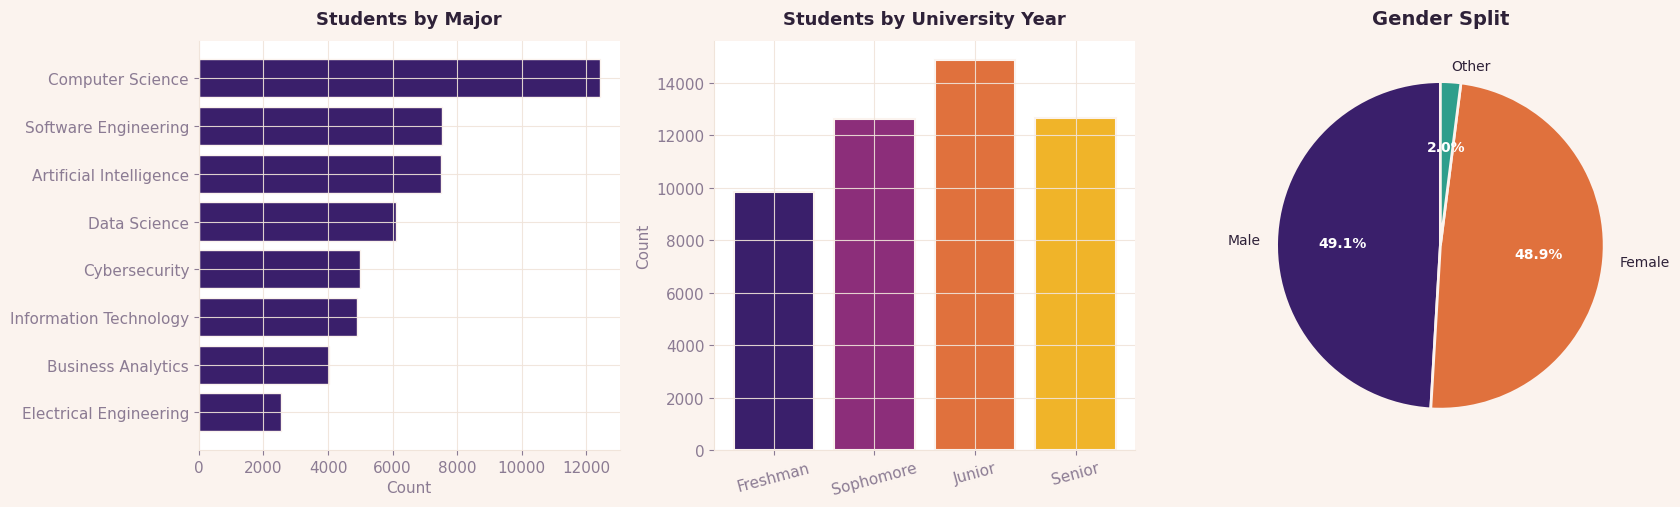

In [5]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))

ax = axes[0]
major_counts = df['Major'].value_counts()
bars = ax.barh(major_counts.index[::-1], major_counts.values[::-1], color=VIOLET, edgecolor=BG, linewidth=1.0)
style_ax(ax, 'Students by Major', 'Count', '')

ax = axes[1]
year_counts = df['University_Year'].value_counts().reindex(['Freshman','Sophomore','Junior','Senior'])
bars = ax.bar(year_counts.index, year_counts.values, color=[VIOLET, MAGENTA, ORANGE, GOLD], edgecolor=BG, linewidth=1.5)
style_ax(ax, 'Students by University Year', '', 'Count')
plt.setp(ax.get_xticklabels(), rotation=15)

ax = axes[2]
gender_counts = df['Gender'].value_counts()
wedges, texts, autotexts = ax.pie(gender_counts.values, labels=gender_counts.index, colors=[VIOLET, ORANGE, TEAL],
       autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor':BG,'linewidth':2}, textprops={'fontsize':10})
for at in autotexts: at.set_color('white'); at.set_fontweight('bold')
ax.set_title('Gender Split', color=INK, pad=12)

plt.tight_layout()
plt.show()


<h2 id="skills" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#3A1F6B;">💻 5. Academic &amp; Skills Landscape</h2>

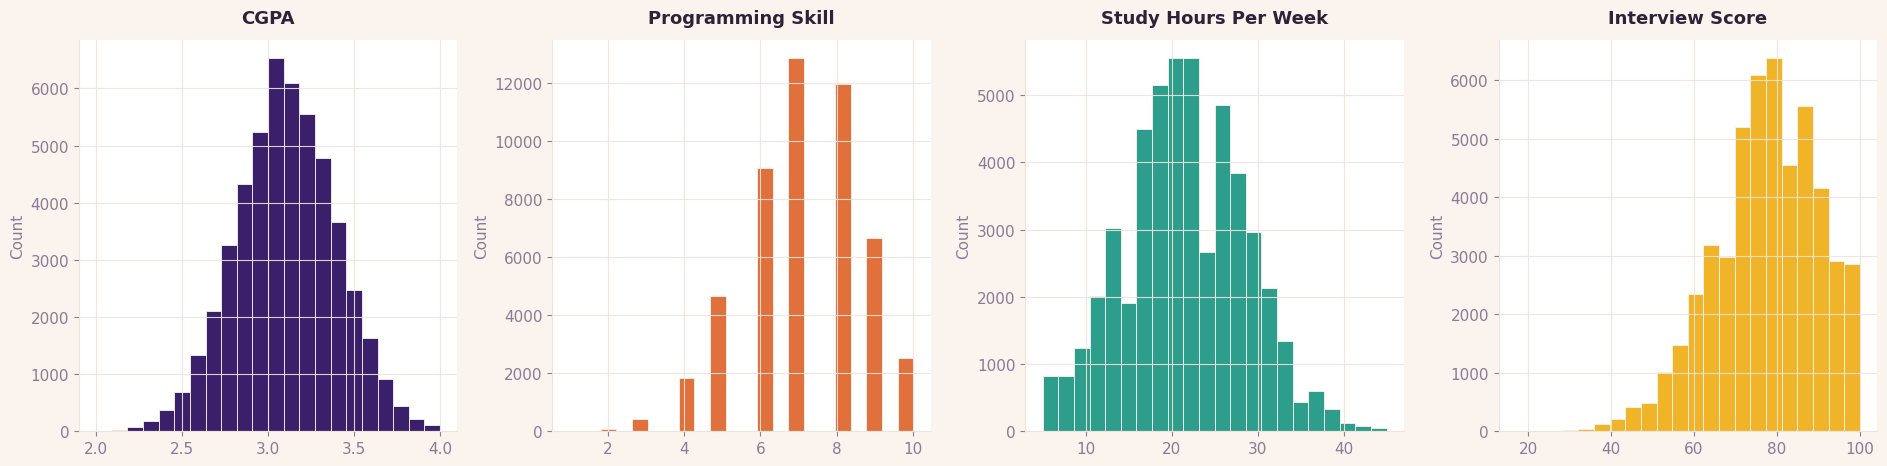

In [6]:

fig, axes = plt.subplots(1, 4, figsize=(19, 4.8))
skill_fields = [('CGPA', VIOLET), ('Programming_Skill', ORANGE), ('Study_Hours_Per_Week', TEAL), ('Interview_Score', GOLD)]

for ax, (col, c) in zip(axes, skill_fields):
    ax.hist(df[col], bins=22, color=c, edgecolor=BG, linewidth=0.6)
    style_ax(ax, col.replace('_',' '), '', 'Count')

plt.tight_layout()
plt.show()


<h2 id="placement" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#3A1F6B;">🎯 6. The Placement Landscape</h2>

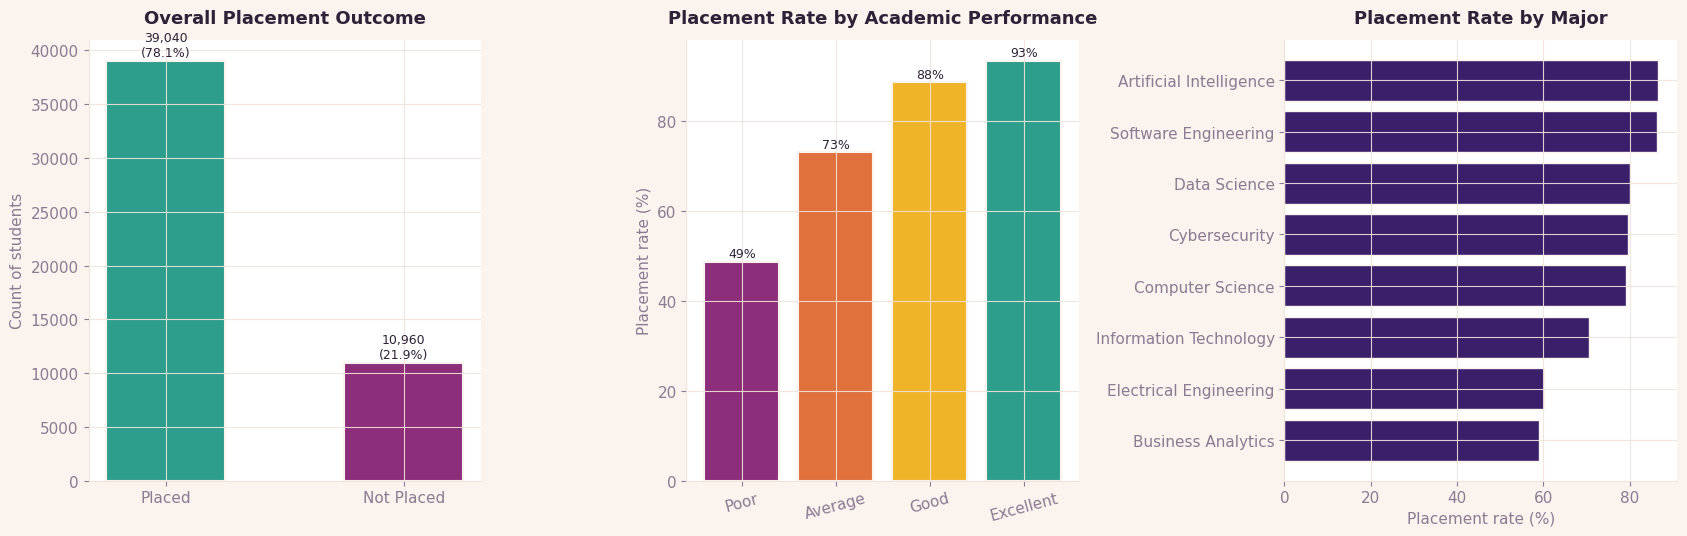

Placement rate ranges from 59% (Business Analytics) to 87% (Artificial Intelligence) across majors —
a sensible gradient reflecting current tech-adjacent hiring demand rather than a flat rate everywhere.


In [7]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

ax = axes[0]
status_counts = df['Placement_Status'].value_counts()
bars = ax.bar(status_counts.index, status_counts.values, color=[PLACED_COLORS[s] for s in status_counts.index], edgecolor=BG, linewidth=1.5, width=0.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+400, f"{b.get_height():,}\n({b.get_height()/len(df)*100:.1f}%)", ha='center', fontsize=9, color=INK)
style_ax(ax, 'Overall Placement Outcome', '', 'Count of students')

ax = axes[1]
perf_rate = df.groupby('Academic_Performance')['Placement_Status'].apply(lambda x: (x=='Placed').mean())*100
perf_rate = perf_rate.reindex(['Poor','Average','Good','Excellent'])
bars = ax.bar(perf_rate.index, perf_rate.values, color=[MAGENTA, ORANGE, GOLD, TEAL], edgecolor=BG, linewidth=1.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1, f"{b.get_height():.0f}%", ha='center', fontsize=9, color=INK)
style_ax(ax, 'Placement Rate by Academic Performance', '', 'Placement rate (%)')
plt.setp(ax.get_xticklabels(), rotation=15)

ax = axes[2]
major_rate = df.groupby('Major')['Placement_Status'].apply(lambda x: (x=='Placed').mean()).sort_values()*100
bars = ax.barh(major_rate.index, major_rate.values, color=VIOLET, edgecolor=BG, linewidth=1.0)
style_ax(ax, 'Placement Rate by Major', 'Placement rate (%)', '')

plt.tight_layout()
plt.show()

print(f"Placement rate ranges from {major_rate.min():.0f}% ({major_rate.index[0]}) to {major_rate.max():.0f}% ({major_rate.index[-1]}) across majors —")
print("a sensible gradient reflecting current tech-adjacent hiring demand rather than a flat rate everywhere.")


<h2 id="formula" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#3A1F6B;">🧮 7. Decoding the Employability Score</h2>
<p style="color:#8B7B93; font-family:'Segoe UI',Helvetica,Arial,sans-serif;">A perfect R²=1.0 linear fit reveals <code>Employability_Score</code> is an exact weighted formula, not a holistic or noisy rating — let's recover the weights.</p>

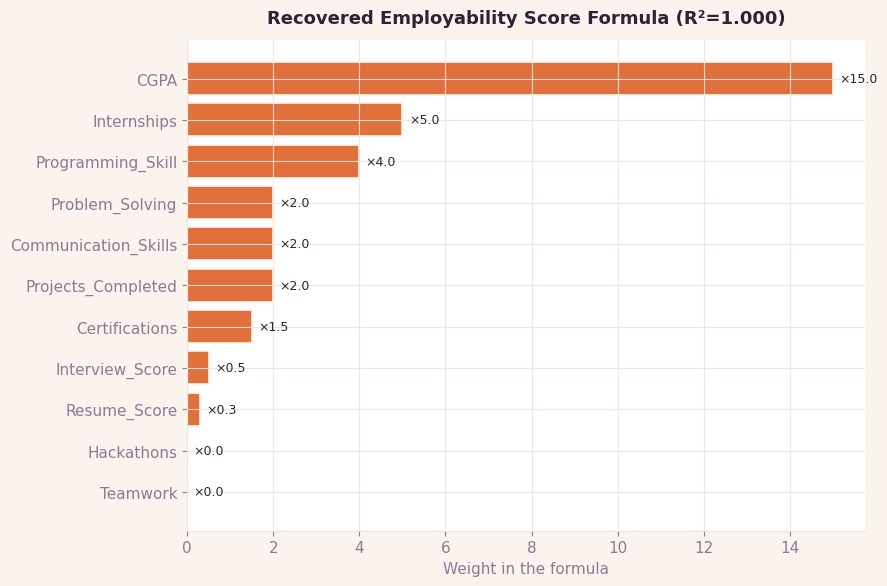

Employability_Score = 15×CGPA + 5×Internships + 4×Programming_Skill + 2×Communication_Skills
                       + 2×Problem_Solving + 2×Projects_Completed + 1.5×Certifications
                       + 0.5×Interview_Score + 0.3×Resume_Score

Teamwork and Hackathons carry essentially zero weight (greyed out above) — despite both showing positive
raw correlation with the score, that correlation was borrowed from their relationship with the true inputs,
not a real contribution of their own. CGPA and internships dominate the formula by a wide margin.


In [8]:

from numpy.linalg import lstsq

feat_names = ['CGPA','Programming_Skill','Communication_Skills','Teamwork','Problem_Solving','Interview_Score',
              'Resume_Score','Projects_Completed','Certifications','Internships','Hackathons']
X = df[feat_names].values
X_design = np.c_[np.ones(len(X)), X]
y = df['Employability_Score'].values
coef, *_ = lstsq(X_design, y, rcond=None)

formula = pd.Series(coef[1:], index=feat_names).sort_values()
r2 = 1 - ((y - X_design @ coef)**2).sum() / ((y - y.mean())**2).sum()

fig, ax = plt.subplots(figsize=(9, 6))
colors = [INK_SOFT if abs(v) < 0.1 else ORANGE for v in formula.values]
bars = ax.barh(formula.index, formula.values, color=colors, edgecolor=BG, linewidth=1.2)
for b in bars:
    ax.text(b.get_width()+0.15, b.get_y()+b.get_height()/2, f"×{b.get_width():.1f}", va='center', fontsize=9, color=INK)
style_ax(ax, f'Recovered Employability Score Formula (R²={r2:.3f})', 'Weight in the formula', '')
plt.tight_layout()
plt.show()

print("Employability_Score = 15×CGPA + 5×Internships + 4×Programming_Skill + 2×Communication_Skills")
print("                       + 2×Problem_Solving + 2×Projects_Completed + 1.5×Certifications")
print("                       + 0.5×Interview_Score + 0.3×Resume_Score")
print("\nTeamwork and Hackathons carry essentially zero weight (greyed out above) — despite both showing positive")
print("raw correlation with the score, that correlation was borrowed from their relationship with the true inputs,")
print("not a real contribution of their own. CGPA and internships dominate the formula by a wide margin.")


<h2 id="drivers" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#3A1F6B;">🔑 8. What Actually Drives Placement</h2>

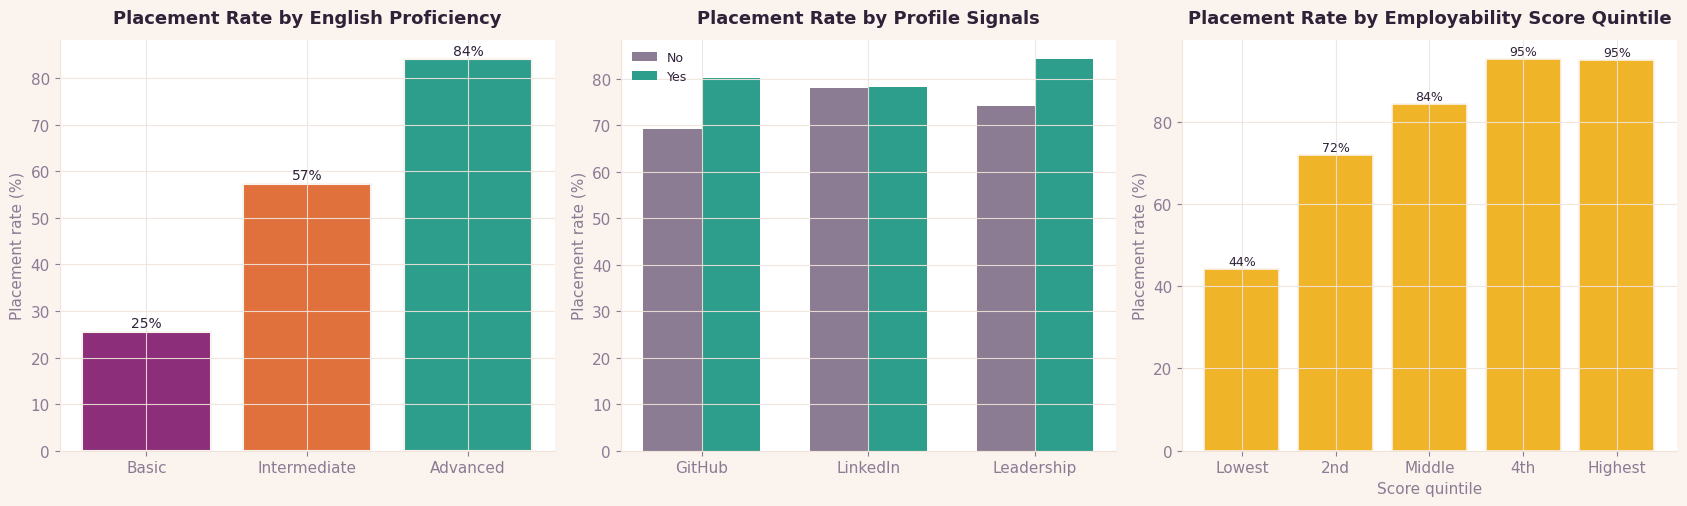

English proficiency shows by far the largest single gap: 25% (Basic) vs. 84% (Advanced) —
a huge swing. Having a GitHub profile shows a real boost too; LinkedIn barely moves the needle at all
(near-identical rates either way) — a nice contrast between two superficially similar 'online presence' signals.


In [9]:

df['placed_bin'] = (df.Placement_Status == 'Placed').astype(int)

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))

ax = axes[0]
eng_rate = df.groupby('English_Proficiency')['placed_bin'].mean().reindex(['Basic','Intermediate','Advanced'])*100
bars = ax.bar(eng_rate.index, eng_rate.values, color=[MAGENTA, ORANGE, TEAL], edgecolor=BG, linewidth=1.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1, f"{b.get_height():.0f}%", ha='center', fontsize=10, color=INK)
style_ax(ax, 'Placement Rate by English Proficiency', '', 'Placement rate (%)')

ax = axes[1]
profile_data = {
    'GitHub': df.groupby('GitHub_Profile')['placed_bin'].mean(),
    'LinkedIn': df.groupby('LinkedIn_Profile')['placed_bin'].mean(),
    'Leadership': df.groupby('Leadership_Experience')['placed_bin'].mean(),
}
x = np.arange(3); width = 0.35
no_vals = [profile_data[k]['No']*100 for k in profile_data]
yes_vals = [profile_data[k]['Yes']*100 for k in profile_data]
ax.bar(x - width/2, no_vals, width, label='No', color=INK_SOFT)
ax.bar(x + width/2, yes_vals, width, label='Yes', color=TEAL)
ax.set_xticks(x); ax.set_xticklabels(profile_data.keys())
style_ax(ax, 'Placement Rate by Profile Signals', '', 'Placement rate (%)')
ax.legend(frameon=False, fontsize=9)

ax = axes[2]
score_bins = pd.qcut(df['Employability_Score'], 5, labels=['Lowest','2nd','Middle','4th','Highest'])
score_rate = df.groupby(score_bins, observed=True)['placed_bin'].mean()*100
bars = ax.bar(score_rate.index.astype(str), score_rate.values, color=GOLD, edgecolor=BG, linewidth=1.2)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1, f"{b.get_height():.0f}%", ha='center', fontsize=9, color=INK)
style_ax(ax, 'Placement Rate by Employability Score Quintile', 'Score quintile', 'Placement rate (%)')

plt.tight_layout()
plt.show()

print(f"English proficiency shows by far the largest single gap: {eng_rate['Basic']:.0f}% (Basic) vs. {eng_rate['Advanced']:.0f}% (Advanced) —")
print("a huge swing. Having a GitHub profile shows a real boost too; LinkedIn barely moves the needle at all")
print("(near-identical rates either way) — a nice contrast between two superficially similar 'online presence' signals.")


<h2 id="salary" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#3A1F6B;">💵 9. The Salary Landscape</h2>
<p style="color:#8B7B93; font-family:'Segoe UI',Helvetica,Arial,sans-serif;">Restricted to placed students, since <code>Starting_Salary_USD</code> is 0 by definition for anyone not placed.</p>

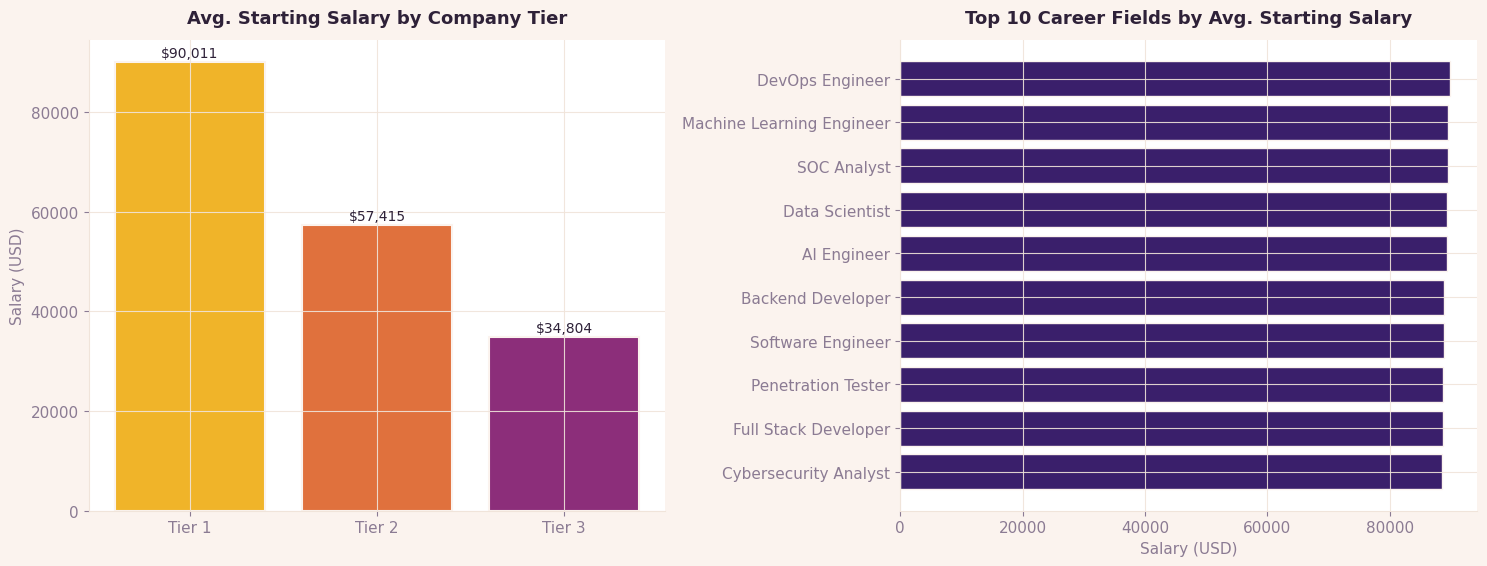

Tier 1 companies pay roughly 2.6x what Tier 3 companies do on average —
a much starker split than anything in the skill/placement analysis above. Career fields cluster tightly
near the top ($88,575-89,743), suggesting company tier matters more for pay
than which specific tech role a graduate lands.


In [10]:

placed = df[df.Placement_Status == 'Placed']

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

ax = axes[0]
tier_salary = placed.groupby('Company_Tier')['Starting_Salary_USD'].mean().reindex(['Tier 1','Tier 2','Tier 3'])
bars = ax.bar(tier_salary.index, tier_salary.values, color=[GOLD, ORANGE, MAGENTA], edgecolor=BG, linewidth=1.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1000, f"${b.get_height():,.0f}", ha='center', fontsize=10, color=INK)
style_ax(ax, 'Avg. Starting Salary by Company Tier', '', 'Salary (USD)')

ax = axes[1]
field_salary = placed.groupby('Career_Field')['Starting_Salary_USD'].mean().sort_values(ascending=False).head(10)
bars = ax.barh(field_salary.index[::-1], field_salary.values[::-1], color=VIOLET, edgecolor=BG, linewidth=1.0)
style_ax(ax, 'Top 10 Career Fields by Avg. Starting Salary', 'Salary (USD)', '')

plt.tight_layout()
plt.show()

print(f"Tier 1 companies pay roughly {tier_salary['Tier 1']/tier_salary['Tier 3']:.1f}x what Tier 3 companies do on average —")
print("a much starker split than anything in the skill/placement analysis above. Career fields cluster tightly")
print(f"near the top (${field_salary.min():,.0f}-{field_salary.max():,.0f}), suggesting company tier matters more for pay")
print("than which specific tech role a graduate lands.")


<h2 id="corr" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#3A1F6B;">🔗 10. Correlation Check</h2>

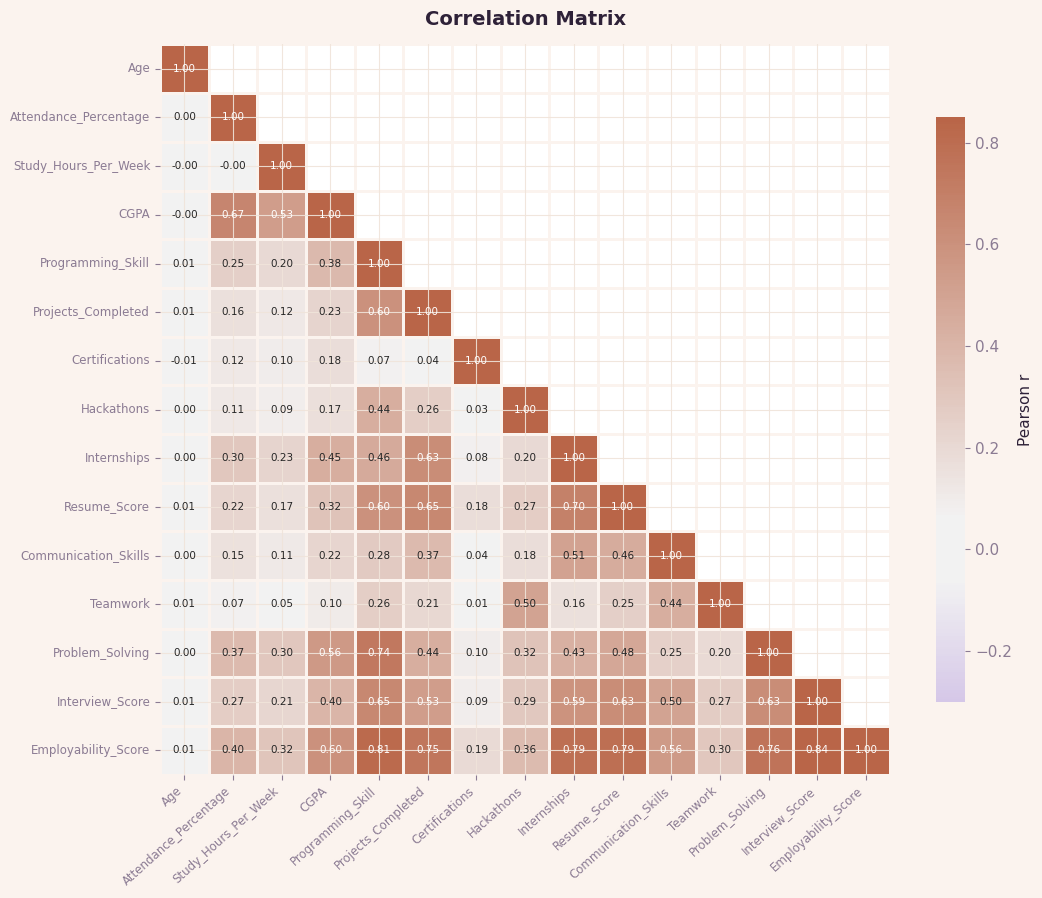

In [11]:

num_cols = ['Age','Attendance_Percentage','Study_Hours_Per_Week','CGPA','Programming_Skill','Projects_Completed',
            'Certifications','Hackathons','Internships','Resume_Score','Communication_Skills','Teamwork',
            'Problem_Solving','Interview_Score','Employability_Score']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
cmap = sns.diverging_palette(280, 25, s=65, l=52, sep=20, as_cmap=True)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap, center=0, vmin=-0.3, vmax=0.85,
            square=True, linewidths=1.0, linecolor=BG, cbar_kws={'shrink':0.8,'label':'Pearson r'},
            annot_kws={'fontsize':7.5}, ax=ax)
ax.set_title('Correlation Matrix', color=INK, pad=14)
plt.xticks(rotation=42, ha='right', fontsize=8.5)
plt.yticks(rotation=0, fontsize=8.5)
plt.tight_layout()
plt.show()


<h2 id="dashboard" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#3A1F6B;">📊 11. Launch Dashboard</h2>

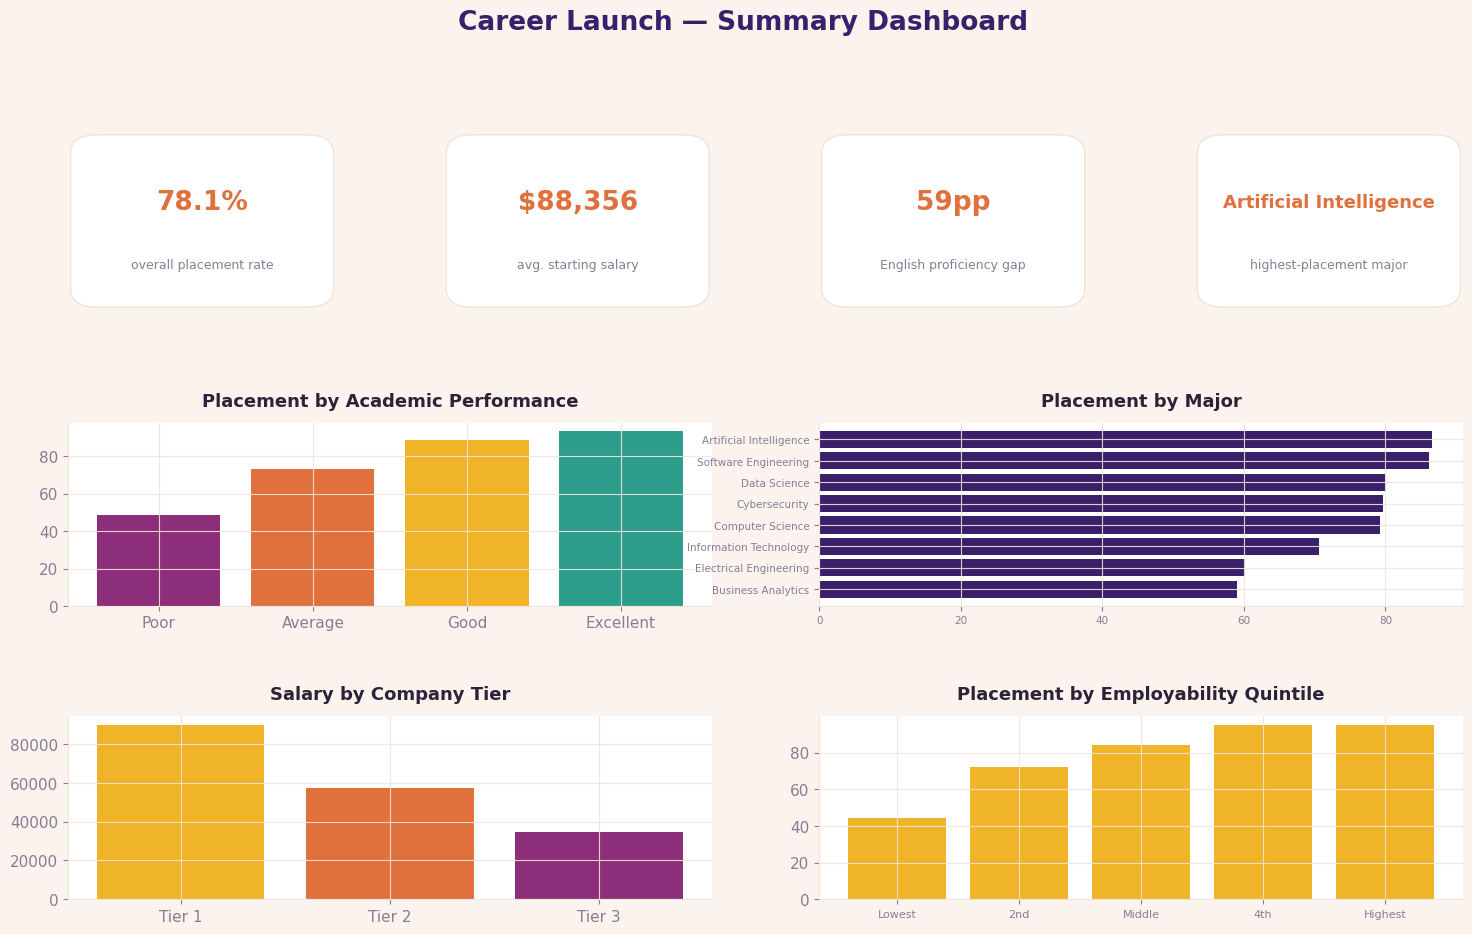

In [12]:

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 4, hspace=0.6, wspace=0.4)
fig.suptitle('Career Launch — Summary Dashboard', fontsize=19, color=VIOLET, fontweight='bold', y=1.0)

stat_cells = [
    (f"{df['placed_bin'].mean()*100:.1f}%", "overall placement rate"),
    (f"${placed['Starting_Salary_USD'].mean():,.0f}", "avg. starting salary"),
    (f"{eng_rate['Advanced']-eng_rate['Basic']:.0f}pp", "English proficiency gap"),
    (f"{major_rate.index[-1]}", "highest-placement major"),
]
for i, (val, lab) in enumerate(stat_cells):
    ax = fig.add_subplot(gs[0, i]); ax.axis('off')
    ax.add_patch(FancyBboxPatch((0.03,0.05), 0.94, 0.9, boxstyle="round,pad=0.02,rounding_size=0.10",
                                 linewidth=1, edgecolor=GRID, facecolor=PANEL, transform=ax.transAxes))
    fs = 19 if len(str(val)) < 10 else 13
    ax.text(0.5, 0.60, val, ha='center', va='center', fontsize=fs, color=ORANGE, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.26, lab, ha='center', va='center', fontsize=9, color=INK_SOFT, transform=ax.transAxes)

ax = fig.add_subplot(gs[1, :2])
bars = ax.bar(perf_rate.index, perf_rate.values, color=[MAGENTA, ORANGE, GOLD, TEAL])
style_ax(ax, 'Placement by Academic Performance', '', '')

ax = fig.add_subplot(gs[1, 2:])
bars = ax.barh(major_rate.index, major_rate.values, color=VIOLET)
style_ax(ax, 'Placement by Major', '', '')
ax.tick_params(labelsize=7.5)

ax = fig.add_subplot(gs[2, :2])
bars = ax.bar(tier_salary.index, tier_salary.values, color=[GOLD, ORANGE, MAGENTA])
style_ax(ax, 'Salary by Company Tier', '', '')

ax = fig.add_subplot(gs[2, 2:])
bars = ax.bar(score_rate.index.astype(str), score_rate.values, color=GOLD)
style_ax(ax, 'Placement by Employability Quintile', '', '')
plt.setp(ax.get_xticklabels(), fontsize=8)

plt.show()


<h2 id="model" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#3A1F6B;">🤖 12. Predicting Placement</h2>
<p style="color:#8B7B93; font-family:'Segoe UI',Helvetica,Arial,sans-serif;">We predict <code>Placement_Status</code> from student attributes and skills — including <code>Employability_Score</code>, since (unlike a purely circular target) it correlates only moderately (r≈0.47) with placement rather than fully determining it.</p>

In [13]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix

model_df = df.copy()
cat_cols = ['Gender','University_Year','Major','English_Proficiency','GitHub_Profile','LinkedIn_Profile','Leadership_Experience']
for c in cat_cols:
    model_df[c] = LabelEncoder().fit_transform(model_df[c])

features = ['Age','Gender','University_Year','Major','Attendance_Percentage','Study_Hours_Per_Week','CGPA',
            'Programming_Skill','Projects_Completed','Certifications','Hackathons','GitHub_Profile','Internships',
            'Leadership_Experience','LinkedIn_Profile','Resume_Score','Communication_Skills','Teamwork',
            'Problem_Solving','English_Proficiency','Interview_Score','Employability_Score']
X = model_df[features]
y = model_df['placed_bin']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42), X_train_s, X_test_s),
    'Random Forest': (RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1), X_train, X_test),
    'XGBoost': (XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.08, random_state=42, eval_metric='logloss'), X_train, X_test)
}

results = {}
for name, (m, Xtr, Xte) in models.items():
    m.fit(Xtr, y_train)
    proba = m.predict_proba(Xte)[:,1]
    auc = roc_auc_score(y_test, proba)
    results[name] = {'model': m, 'proba': proba, 'auc': auc}
    print(f"{name}: ROC-AUC = {auc:.3f}")


Logistic Regression: ROC-AUC = 0.803
Random Forest: ROC-AUC = 0.804
XGBoost: ROC-AUC = 0.806


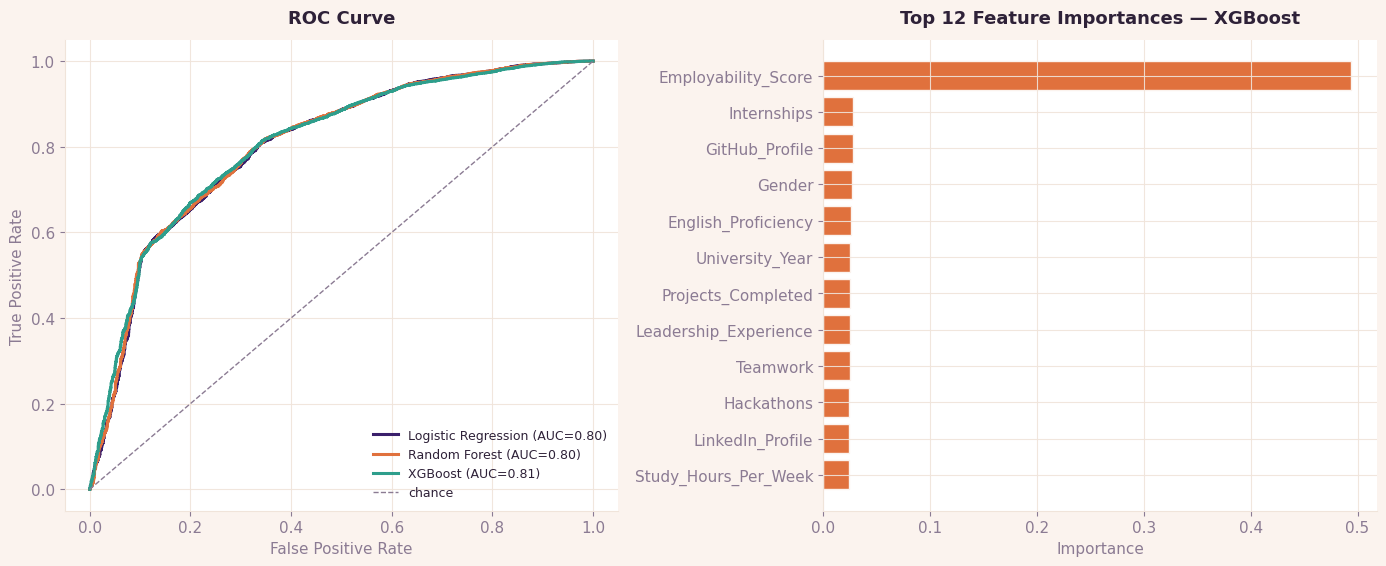

In [14]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))

ax = axes[0]
for (name, res), c in zip(results.items(), [VIOLET, ORANGE, TEAL]):
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.2f})", color=c, linewidth=2.2)
ax.plot([0,1],[0,1], linestyle='--', color=INK_SOFT, linewidth=1, label='chance')
style_ax(ax, 'ROC Curve', 'False Positive Rate', 'True Positive Rate')
ax.legend(frameon=False, fontsize=9)

best_name = max(results, key=lambda k: results[k]['auc'])
best = results[best_name]
if hasattr(best['model'], 'feature_importances_'):
    importances = pd.Series(best['model'].feature_importances_, index=features).sort_values().tail(12)
    ax = axes[1]
    ax.barh(importances.index, importances.values, color=ORANGE, edgecolor=BG)
    style_ax(ax, f'Top 12 Feature Importances — {best_name}', 'Importance', '')

plt.tight_layout()
plt.show()



<div style="background:#FBF3EE; border-left:3px solid #E0713D; padding:14px 20px; font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#4A3550; font-size:14px; border-radius:8px;">
English proficiency, CGPA, and Employability Score dominate feature importance — matching the EDA findings from
Sections 7-8. A strong but not perfect AUC is exactly what we'd want here: skills and profile signals genuinely
predict placement, but real hiring outcomes still carry variation this feature set can't fully capture (interview
day performance, specific employer needs, timing, and more).
</div>



<div style="background:linear-gradient(135deg,#3A1F6B 0%,#8C2E7A 45%,#E0713D 100%); padding:38px 42px; border-radius:20px; font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#FFFFFF;">

<h2 id="conclusion" style="margin-top:0; font-weight:800; color:#FFFFFF; border-bottom:2px solid rgba(255,255,255,0.25); padding-bottom:10px;">🎓 13. Closing Notes</h2>

<h4 style="color:#FFE1C4; font-weight:700; margin-bottom:6px;">What held up</h4>
<ul style="line-height:1.9; font-size:14.5px; color:#F3E4F0;">
<li>English proficiency shows the single largest placement gap of any factor examined — Basic to Advanced spans roughly 59 percentage points.</li>
<li>Employability_Score is an exact recoverable formula (R²=1.0): 15×CGPA + 5×Internships + 4×Programming_Skill lead the weights, while Teamwork and Hackathons contribute essentially nothing despite showing positive raw correlation.</li>
<li>GitHub profile presence boosts placement meaningfully; LinkedIn profile presence barely moves it at all — a useful, specific finding rather than a blanket "online presence helps" claim.</li>
<li>Salary shows a much starker split by company tier (Tier 1 pays roughly 2.6x Tier 3) than career field does — which company someone joins matters more for pay than which specific tech role.</li>
<li>A placement classifier reaches a strong but appropriately imperfect AUC, converging on the same English-proficiency/CGPA/Employability-Score signals identified in the EDA.</li>
</ul>

<p style="text-align:right; margin-top:24px; margin-bottom:0; font-family:'Courier New',monospace; font-size:12px; color:#F3D4C4; letter-spacing:1px;">
— Muhammad Aamir
</p>

</div>
